In [3]:
# ============================================================
# SCRIPT 1: extract_serie_a.py — versione corretta
# ============================================================

import json
import pandas as pd
from pathlib import Path

# --- PATH CONFIGURAZIONE ---
BASE_DIR   = Path("/Volumes/EUfutbol/testeo_ligas_europa/Italy_Serie_A")
OUTPUT_DIR = Path("/Volumes/EUfutbol/pv_training")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# RIMOSSO qualifierId 107 (assist_player_id) — tipo misto, non utile per PV
QUALIFIER_MAP = {
    72:  "through_ball",
    2:   "cross",
    73:  "aerial",
    18:  "head",
    140: "pass_end_x",
    141: "pass_end_y",
    56:  "zone",
    102: "distance_to_goal",
    103: "angle_to_goal",
    212: "pass_length",
    279: "pass_zone",
}

USEFUL_TYPE_IDS = {
    1, 2, 3, 7, 8, 12, 13, 14, 15, 16, 44, 49, 61
}

VALID_PERIODS = {1, 2, 5, 6}


def parse_qualifiers(qualifier_list: list) -> dict:
    result = {}
    for q in qualifier_list:
        qid = q.get("qualifierId")
        if qid in QUALIFIER_MAP:
            col_name = QUALIFIER_MAP[qid]
            result[col_name] = q.get("value", 1)
    return result


def parse_match_file(json_path: Path) -> pd.DataFrame:
    data = None
    for encoding in ["utf-8", "latin-1", "utf-8-sig"]:
        try:
            with open(json_path, encoding=encoding) as f:
                data = json.load(f)
            break
        except (UnicodeDecodeError, json.JSONDecodeError):
            continue

    if data is None:
        raise ValueError(f"Impossibile leggere {json_path.name} con nessun encoding")

    match_info  = data["matchInfo"]
    match_id    = match_info["id"]
    season      = match_info["tournamentCalendar"]["name"]
    contestants = {c["id"]: c["name"] for c in match_info["contestant"]}
    events      = data["liveData"]["event"]

    rows = []
    for ev in events:
        period_id = ev.get("periodId")
        type_id   = ev.get("typeId")

        if period_id not in VALID_PERIODS:
            continue
        if type_id not in USEFUL_TYPE_IDS:
            continue

        x = ev.get("x")
        y = ev.get("y")
        if x is None or y is None:
            continue

        row = {
            "match_id":    match_id,
            "season":      season,
            "event_id":    ev.get("id"),
            "period_id":   period_id,
            "minute":      ev.get("timeMin"),
            "second":      ev.get("timeSec"),
            "team_id":     ev.get("contestantId"),
            "team_name":   contestants.get(ev.get("contestantId"), ""),
            "player_id":   ev.get("playerId", ""),
            "player_name": ev.get("playerName", ""),
            "type_id":     type_id,
            "outcome":     ev.get("outcome"),
            "x":           float(x),
            "y":           float(y),
        }

        qualifiers = parse_qualifiers(ev.get("qualifier", []))
        row.update(qualifiers)
        rows.append(row)

    return pd.DataFrame(rows)


# --- MAIN LOOP ---
all_chunks   = []
seasons_found = []
total_errors = 0

season_dirs = sorted([
    d for d in BASE_DIR.iterdir()
    if d.is_dir() and not d.name.startswith(".")
])

print(f"Stagioni trovate: {[d.name for d in season_dirs]}\n")

for season_dir in season_dirs:
    partidos_dir = season_dir / "partidos"
    if not partidos_dir.exists():
        print(f"  ⚠️  Nessuna cartella partidos in {season_dir.name}")
        continue

    json_files = sorted([
        f for f in partidos_dir.glob("*.json")
        if not f.name.startswith("._")
    ])

    print(f"📁 {season_dir.name}: {len(json_files)} partite")

    season_chunks = []
    for jf in json_files:
        try:
            df = parse_match_file(jf)
            if not df.empty:
                season_chunks.append(df)
        except Exception as e:
            total_errors += 1
            print(f"    ✗ {jf.name}: {e}")

    if season_chunks:
        season_df = pd.concat(season_chunks, ignore_index=True)
        print(f"    ✓ {len(season_df):,} eventi estratti")
        all_chunks.append(season_df)
        seasons_found.append(season_dir.name)

# --- PULIZIA E SALVATAGGIO ---
if not all_chunks:
    print("\n⚠️  Nessun dato estratto — controlla i path")
else:
    print("\nConcatenating tutte le stagioni...")
    full_df = pd.concat(all_chunks, ignore_index=True)

    # Tipi base
    full_df["x"]         = full_df["x"].astype("float32")
    full_df["y"]         = full_df["y"].astype("float32")
    full_df["type_id"]   = full_df["type_id"].astype("int16")
    full_df["minute"]    = pd.to_numeric(full_df["minute"], errors="coerce").astype("Int16")
    full_df["second"]    = pd.to_numeric(full_df["second"], errors="coerce").astype("Int16")
    full_df["period_id"] = full_df["period_id"].astype("int8")
    full_df["outcome"]   = pd.to_numeric(full_df["outcome"], errors="coerce").astype("Int8")

    # Colonne numeriche da qualifier
    NUMERIC_QUALIFIER_COLS = [
        "pass_end_x", "pass_end_y", "distance_to_goal",
        "angle_to_goal", "pass_length"
    ]
    for col in NUMERIC_QUALIFIER_COLS:
        if col in full_df.columns:
            full_df[col] = pd.to_numeric(full_df[col], errors="coerce").astype("float32")

    # Colonne flag → 0/1
    FLAG_COLS = ["through_ball", "cross", "aerial", "head"]
    for col in FLAG_COLS:
        if col in full_df.columns:
            full_df[col] = pd.to_numeric(full_df[col], errors="coerce").fillna(0).astype("int8")

    # Colonne stringa
    STRING_COLS = ["zone", "pass_zone"]
    for col in STRING_COLS:
        if col in full_df.columns:
            full_df[col] = full_df[col].astype(str).replace("nan", "")

    output_path = OUTPUT_DIR / "serie_a_events_raw.parquet"
    full_df.to_parquet(output_path, index=False, compression="snappy")

    print(f"\n✅ Salvato: {output_path}")
    print(f"   Righe totali  : {len(full_df):,}")
    print(f"   Stagioni      : {seasons_found}")
    print(f"   Errori totali : {total_errors}")
    print(f"   Dimensione    : {output_path.stat().st_size / 1e6:.1f} MB")
    print(f"\nColonne:\n{list(full_df.columns)}")
    print(f"\nDistribuzione type_id:\n{full_df['type_id'].value_counts().sort_index()}")

Stagioni trovate: ['2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026']

📁 2008-2009: 380 partite
    ✓ 460,162 eventi estratti
📁 2009-2010: 380 partite
    ✓ 468,531 eventi estratti
📁 2010-2011: 380 partite
    ✓ 502,488 eventi estratti
📁 2011-2012: 380 partite
    ✓ 516,631 eventi estratti
📁 2012-2013: 380 partite
    ✗ 4_Cagliari_Roma_cpxbcxx7bhebputebat7h1z2t.json: 'matchInfo'
    ✓ 519,543 eventi estratti
📁 2013-2014: 380 partite
    ✓ 509,947 eventi estratti
📁 2014-2015: 380 partite
    ✓ 512,879 eventi estratti
📁 2015-2016: 380 partite
    ✓ 516,504 eventi estratti
📁 2016-2017: 380 partite
    ✓ 526,375 eventi estratti
📁 2017-2018: 380 partite
    ✓ 531,136 eventi estratti
📁 2018-2019: 380 partite
    ✓ 521,849 eventi estratti
📁 2019-2020: 380 partite
    ✓ 515,299 eventi estratti
📁 2020-2021: 380 par

In [4]:
# ============================================================
# SCRIPT 2: add_pv_labels.py
# Aggiunge labels per il training del PV model
# Lancia DOPO extract_serie_a.py
# ============================================================

import pandas as pd
from pathlib import Path

INPUT  = Path("/Volumes/EUfutbol/pv_training/serie_a_events_raw.parquet")
OUTPUT = Path("/Volumes/EUfutbol/pv_training/serie_a_pv_labelled.parquet")

SHOT_TYPE_IDS = {13, 14, 15, 16}
GOAL_TYPE_ID  = 16

print("Caricamento dati...")
df = pd.read_parquet(INPUT)
print(f"Righe caricate: {len(df):,}")
print(f"Colonne: {list(df.columns)}\n")

# --- Ordina per match → period → minute → second → event_id ---
df = df.sort_values(
    ["match_id", "period_id", "minute", "second", "event_id"]
).reset_index(drop=True)

# --- Calcola _match_sec per gap temporale ---
df["_match_sec"] = (
    df["period_id"].astype(int) * 5400 +
    df["minute"].astype(int) * 60 +
    df["second"].astype(int)
)

# --- Assegna possession ID ---
# Nuova possesso quando: cambia team, cambia match, o gap > 5 secondi
team_change = (
    (df["team_id"]  != df["team_id"].shift(1)) |
    (df["match_id"] != df["match_id"].shift(1))
)
time_gap = df["_match_sec"].diff().fillna(0).abs() > 5

df["poss_id"] = (team_change | time_gap).cumsum()

print(f"Possessi totali identificati: {df['poss_id'].nunique():,}")

# --- Labels per possesso ---
# Per ogni poss_id: termina in shot? in goal?
poss_labels = (
    df.groupby("poss_id")["type_id"]
    .agg(
        ends_in_shot=lambda x: int(x.isin(SHOT_TYPE_IDS).any()),
        ends_in_goal=lambda x: int((x == GOAL_TYPE_ID).any())
    )
    .reset_index()
)

df = df.merge(poss_labels, on="poss_id", how="left")

# --- Rimuovi i tiri stessi dal training set ---
# Il modello predice il valore PRIMA del tiro, non durante
df_model = df[~df["type_id"].isin(SHOT_TYPE_IDS)].copy()

# --- Rimuovi colonne helper ---
df_model = df_model.drop(columns=["_match_sec"])

# --- Salva ---
df_model.to_parquet(OUTPUT, index=False, compression="snappy")

print(f"\n✅ Dataset PV labelled salvato: {OUTPUT}")
print(f"   Righe totali (no shots) : {len(df_model):,}")
print(f"   Dimensione              : {OUTPUT.stat().st_size / 1e6:.1f} MB")
print(f"\nDistribuzione labels:")
print(f"   ends_in_shot → {df_model['ends_in_shot'].value_counts().to_dict()}")
print(f"   ends_in_goal → {df_model['ends_in_goal'].value_counts().to_dict()}")
print(f"\nColonne finali:\n{list(df_model.columns)}")

Caricamento dati...
Righe caricate: 8,827,561
Colonne: ['match_id', 'season', 'event_id', 'period_id', 'minute', 'second', 'team_id', 'team_name', 'player_id', 'player_name', 'type_id', 'outcome', 'x', 'y', 'pass_end_x', 'pass_end_y', 'zone', 'angle_to_goal', 'through_ball', 'distance_to_goal', 'cross', 'head', 'aerial', 'pass_length', 'pass_zone']

Possessi totali identificati: 3,266,254

✅ Dataset PV labelled salvato: /Volumes/EUfutbol/pv_training/serie_a_pv_labelled.parquet
   Righe totali (no shots) : 8,652,634
   Dimensione              : 168.5 MB

Distribuzione labels:
   ends_in_shot → {0: 8208924, 1: 443710}
   ends_in_goal → {0: 8607947, 1: 44687}

Colonne finali:
['match_id', 'season', 'event_id', 'period_id', 'minute', 'second', 'team_id', 'team_name', 'player_id', 'player_name', 'type_id', 'outcome', 'x', 'y', 'pass_end_x', 'pass_end_y', 'zone', 'angle_to_goal', 'through_ball', 'distance_to_goal', 'cross', 'head', 'aerial', 'pass_length', 'pass_zone', 'poss_id', 'ends_in_sh

Caricamento dati...
Righe: 8,652,634
Righe valide dopo grid assignment: 8,652,634

Celle totali nella griglia : 192
Celle con dati             : 192

Top 10 celle per xT (zone più pericolose):
 cell_x  cell_y  total   p_shot  p_goal_given_shot       xT
     15       6   3203 0.310958           0.182731 0.056822
     15       5   3167 0.297758           0.176034 0.052416
     15       4   4446 0.244939           0.200184 0.049033
     15       7   4313 0.227452           0.193680 0.044053
     15       3  10482 0.190994           0.198302 0.037874
     14       4   9500 0.262842           0.142171 0.037368
     14       7   9822 0.261658           0.136965 0.035838
     14       5  14136 0.317629           0.109131 0.034663
     14       6  13856 0.327295           0.105623 0.034570
     14       3  11972 0.224942           0.150761 0.033912

✅ Modello salvato: /Users/ricki/Local Projects/FMP_SerieA_Dashboard/dash_app/src/models/pv_model_serie_a.pkl
   Grid shape : (16, 12)
   xT max   

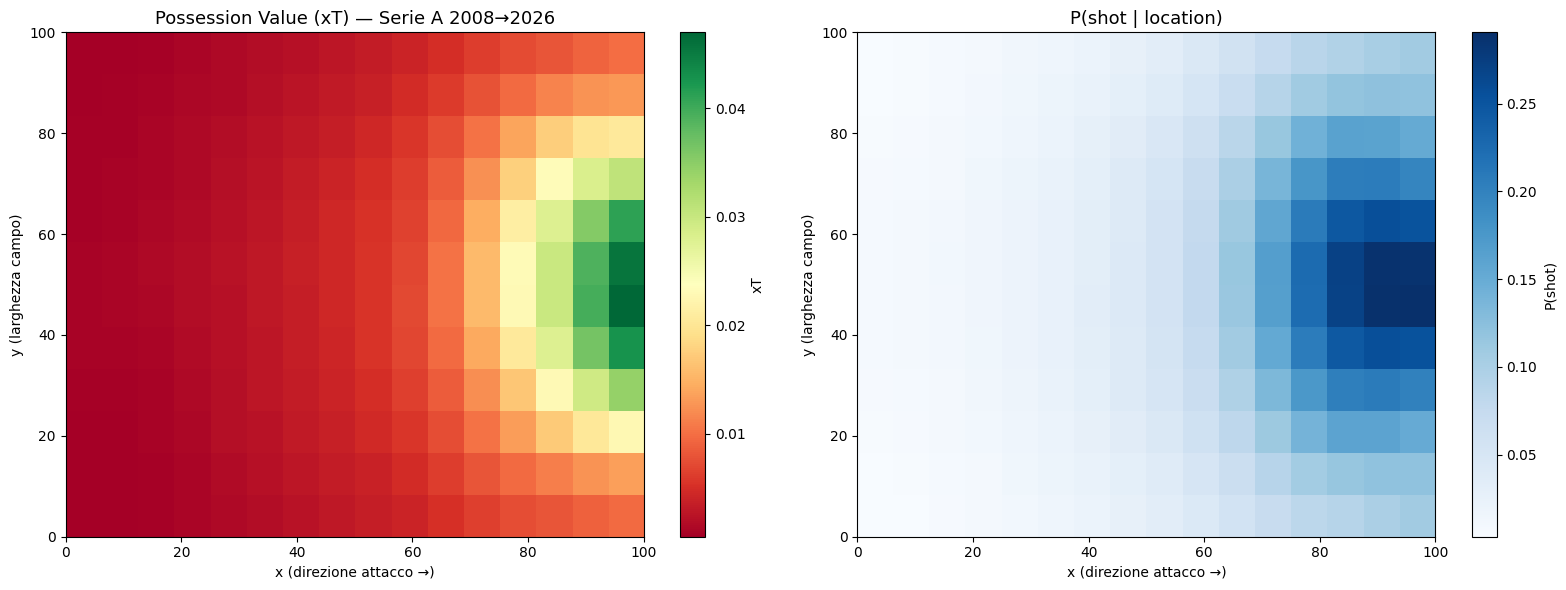

In [5]:
# ============================================================
# SCRIPT 3: train_pv_model.py
# Addestra il modello Possession Value (xT-style grid)
# su dati Serie A e salva il modello per il dashboard
# ============================================================

import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from scipy.ndimage import uniform_filter

# --- PATH ---
INPUT      = Path("/Users/ricki/Local Projects/FMP_SerieA_Dashboard/data/serie_a_pv_labelled.parquet")
OUTPUT_DIR = Path("/Users/ricki/Local Projects/FMP_SerieA_Dashboard/dash_app/src/models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- GRID CONFIGURATION ---
N_X = 16
N_Y = 12

print("Caricamento dati...")
df = pd.read_parquet(INPUT, columns=["x", "y", "ends_in_shot", "ends_in_goal"])
print(f"Righe: {len(df):,}")

# --- STEP 1: Assegna ogni evento a una cella della griglia ---
df["cell_x"] = pd.cut(df["x"], bins=N_X, labels=False).astype("Int16")
df["cell_y"] = pd.cut(df["y"], bins=N_Y, labels=False).astype("Int16")

df = df.dropna(subset=["cell_x", "cell_y"])
df["cell_x"] = df["cell_x"].astype(int)
df["cell_y"] = df["cell_y"].astype(int)

print(f"Righe valide dopo grid assignment: {len(df):,}")

# --- STEP 2: Calcola statistiche per cella ---
cell_stats = (
    df.groupby(["cell_x", "cell_y"])
    .agg(
        total=("ends_in_shot", "count"),
        shots=("ends_in_shot", "sum"),
        goals=("ends_in_goal", "sum"),
    )
    .reset_index()
)

cell_stats["p_shot"] = cell_stats["shots"] / cell_stats["total"]

cell_stats["p_goal_given_shot"] = np.where(
    cell_stats["shots"] > 0,
    cell_stats["goals"] / cell_stats["shots"],
    0.0
)

# --- STEP 3: xT(cell) = P(shot|cell) × P(goal|shot,cell) ---
cell_stats["xT"] = cell_stats["p_shot"] * cell_stats["p_goal_given_shot"]

print(f"\nCelle totali nella griglia : {N_X * N_Y}")
print(f"Celle con dati             : {len(cell_stats)}")
print(f"\nTop 10 celle per xT (zone più pericolose):")
print(
    cell_stats.nlargest(10, "xT")[
        ["cell_x", "cell_y", "total", "p_shot", "p_goal_given_shot", "xT"]
    ].to_string(index=False)
)

# --- STEP 4: Costruisci la griglia xT come array 2D ---
xT_grid     = np.zeros((N_X, N_Y))
p_shot_grid = np.zeros((N_X, N_Y))

for _, row in cell_stats.iterrows():
    cx, cy = int(row["cell_x"]), int(row["cell_y"])
    xT_grid[cx, cy]     = row["xT"]
    p_shot_grid[cx, cy] = row["p_shot"]

# --- STEP 5: Smoothing leggero (media mobile 3x3) ---
xT_grid_smooth     = uniform_filter(xT_grid, size=3)
p_shot_grid_smooth = uniform_filter(p_shot_grid, size=3)

# --- STEP 6: Salva il modello ---
model = {
    "xT_grid":      xT_grid_smooth,
    "p_shot_grid":  p_shot_grid_smooth,
    "n_x":          N_X,
    "n_y":          N_Y,
    "x_bins":       np.linspace(0, 100, N_X + 1),
    "y_bins":       np.linspace(0, 100, N_Y + 1),
    "trained_on":   "Italy_Serie_A",
    "seasons":      "2008-2009 → 2025-2026",
    "total_events": len(df),
    "cell_stats":   cell_stats,
}

model_path = OUTPUT_DIR / "pv_model_serie_a.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)

print(f"\n✅ Modello salvato: {model_path}")
print(f"   Grid shape : {xT_grid_smooth.shape}")
print(f"   xT max     : {xT_grid_smooth.max():.4f}  (zona più pericolosa)")
print(f"   xT mean    : {xT_grid_smooth.mean():.4f}")
print(f"   xT median  : {np.median(xT_grid_smooth):.4f}")

# --- STEP 7: Heatmap di verifica ---
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    im1 = axes[0].imshow(
        xT_grid_smooth.T,
        origin="lower",
        extent=[0, 100, 0, 100],
        cmap="RdYlGn",
        aspect="auto"
    )
    axes[0].set_title("Possession Value (xT) — Serie A 2008→2026", fontsize=13)
    axes[0].set_xlabel("x (direzione attacco →)")
    axes[0].set_ylabel("y (larghezza campo)")
    plt.colorbar(im1, ax=axes[0], label="xT")

    im2 = axes[1].imshow(
        p_shot_grid_smooth.T,
        origin="lower",
        extent=[0, 100, 0, 100],
        cmap="Blues",
        aspect="auto"
    )
    axes[1].set_title("P(shot | location)", fontsize=13)
    axes[1].set_xlabel("x (direzione attacco →)")
    axes[1].set_ylabel("y (larghezza campo)")
    plt.colorbar(im2, ax=axes[1], label="P(shot)")

    plt.tight_layout()
    plot_path = OUTPUT_DIR / "pv_model_heatmap.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    print(f"\n📊 Heatmap salvata: {plot_path}")
    plt.show()

except ImportError:
    print("\n(matplotlib non disponibile — skip heatmap)")